In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import umap
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

2026-03-17 10:54:40.753240: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
csv_path = "../data/link_invent_outputs/scored_sampling_test_protac_optimized_full.csv"
df = pd.read_csv(csv_path)

smi_col = 'SMILES'  
df = df.dropna(subset=[smi_col, 'Active_Probability']).reset_index(drop=True)

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
fps = []
valid_indices = []

for i, s in enumerate(df[smi_col]):
    if pd.notna(s):
        m = Chem.MolFromSmiles(s)
        if m:
            fps.append(mfpgen.GetFingerprintAsNumPy(m))
            valid_indices.append(i)

fps_array = np.array(fps)
df_valid = df.iloc[valid_indices].copy()

reducer = umap.UMAP(n_neighbors=8, min_dist=0.4, metric='jaccard', random_state=42)
embedding = reducer.fit_transform(fps_array)

/home/va.melnyk@ad.loc/anaconda3/envs/protacs/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/va.melnyk@ad.loc/anaconda3/envs/protacs/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_488260/2327044061.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


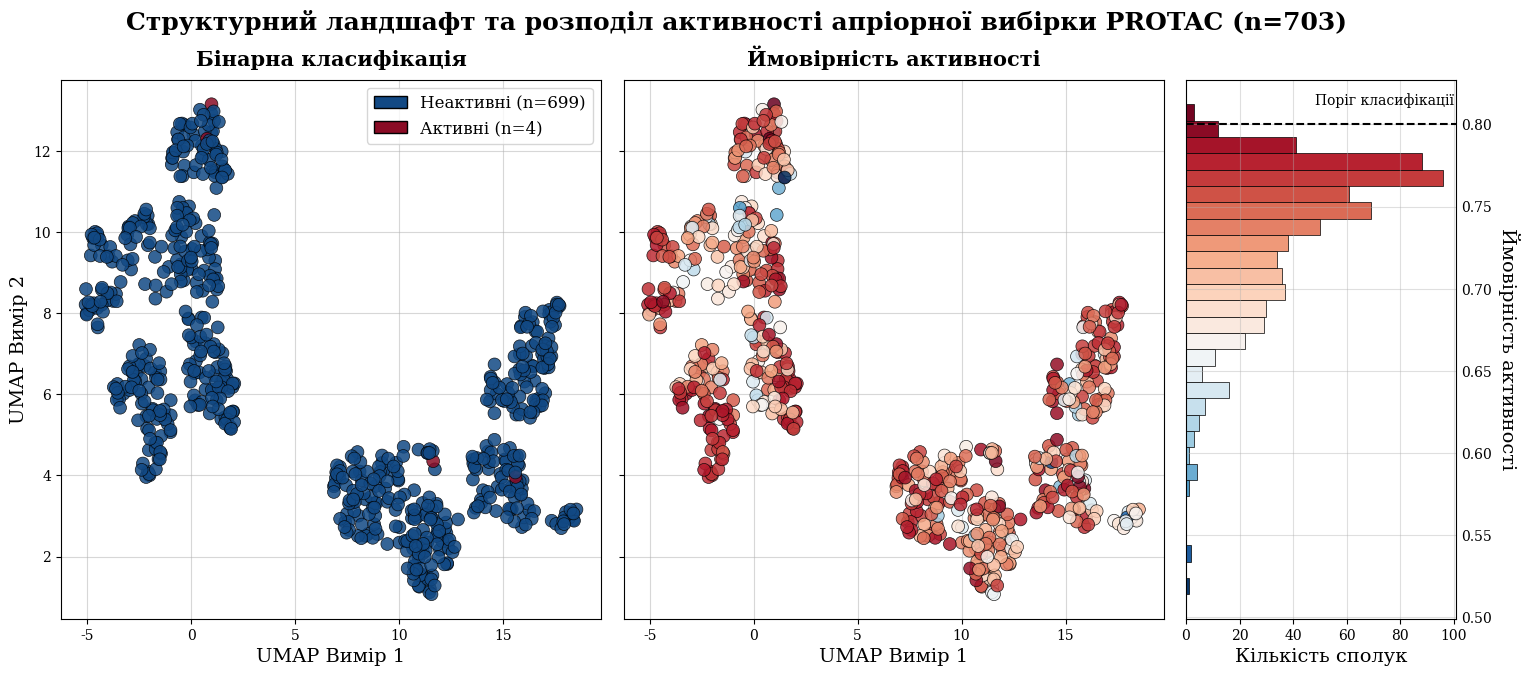

In [11]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.unicode_minus'] = False

# --- DYNAMIC COLOR MAPPING ---
# Calculate the exact boundaries of your actual predictions
prob_min = df_valid['Active_Probability'].min()
prob_max = df_valid['Active_Probability'].max()

# The colormap will now stretch perfectly from prob_min to prob_max
norm = Normalize(vmin=prob_min, vmax=prob_max)
cmap = plt.get_cmap('RdBu_r')

# --- 1x3 Layout ---
fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.05)

ax_umap_class = plt.subplot(gs[0])
ax_umap_prob = plt.subplot(gs[1])
ax_hist = plt.subplot(gs[2]) 

# --- UMAP Plot 1: Binary Class ---
# Extract exact colors from the RdBu_r colormap extremes for the binary plot
color_inactive = cmap(0.05) # Deep Red
color_active = cmap(0.95)   # Deep Blue
class_colors = [color_active if val == 1 else color_inactive for val in df_valid['Active_Class']]

ax_umap_class.scatter(
    embedding[:, 0], embedding[:, 1], 
    c=class_colors, 
    s=85, 
    alpha=0.85, 
    edgecolor='black', 
    linewidth=0.5,
    zorder=3
)

ax_umap_class.set_title('Бінарна класифікація', fontsize=15, fontweight='bold', pad=10)
ax_umap_class.set_xlabel('UMAP Вимір 1', fontsize=14)
ax_umap_class.set_ylabel('UMAP Вимір 2', fontsize=14)
ax_umap_class.grid(True, linestyle='-', alpha=0.5, zorder=1)

# Calculate counts for each class
num_active = (df_valid['Active_Class'] == 1).sum()
num_inactive = (df_valid['Active_Class'] == 0).sum()

# Custom legend for binary class with counts
legend_elements = [
    mpatches.Circle((0, 0), radius=5, facecolor=color_inactive, edgecolor='black', label=f'Неактивні (n={num_inactive})'),
    mpatches.Circle((0, 0), radius=5, facecolor=color_active, edgecolor='black', label=f'Активні (n={num_active})')
]
ax_umap_class.legend(handles=legend_elements, loc='best', fontsize=12)

# --- UMAP Plot 2: Continuous Probability ---
scatter_prob = ax_umap_prob.scatter(
    embedding[:, 0], embedding[:, 1], 
    c=df_valid['Active_Probability'], 
    cmap=cmap, 
    norm=norm,
    s=85, 
    alpha=0.85, 
    edgecolor='black', 
    linewidth=0.5,
    zorder=3
)

ax_umap_prob.set_title('Ймовірність активності', fontsize=15, fontweight='bold', pad=10)
ax_umap_prob.set_xlabel('UMAP Вимір 1', fontsize=14)
ax_umap_prob.grid(True, linestyle='-', alpha=0.5, zorder=1)
# Remove y-ticks for the middle plot to keep it clean
ax_umap_prob.set_yticklabels([])
#ax_umap_prob.set_yticks([])

fig.suptitle(f'Структурний ландшафт та розподіл активності апріорної вибірки PROTAC (n={len(df_valid)})', 
             fontsize=18, 
             fontweight='bold', 
             y=0.98)

# --- Vertical Gradient Histogram (The "Dynamic Colorbar") ---
n_bins = 30
counts, bins, patches = ax_hist.hist(
    df_valid['Active_Probability'], 
    bins=n_bins, 
    range=(prob_min, prob_max), # Lock histogram to the actual data range
    orientation='horizontal', 
    edgecolor='black', 
    linewidth=0.5
)

# Color each bar based on the exact center of its probability bin
for bin_left, bin_right, patch in zip(bins[:-1], bins[1:], patches):
    bin_center = (bin_left + bin_right) / 2
    color = cmap(norm(bin_center))
    patch.set_facecolor(color)

ax_hist.set_xlabel('Кількість сполук', fontsize=14)
ax_hist.set_ylabel('Ймовірність активності', fontsize=14, rotation=270, labelpad=20)
ax_hist.grid(True, axis='y', linestyle='-', alpha=0.4)
ax_hist.grid(True, axis='x', linestyle='-', alpha=0.4)
ax_hist.yaxis.set_label_position("right")
ax_hist.yaxis.tick_right()
ax_hist.tick_params(axis='y', which='both', length=0)

# Add a horizontal dashed line showing your optimal threshold
optimal_threshold = 0.8
ax_hist.axhline(optimal_threshold, color='black', linestyle='--', linewidth=1.5, zorder=5)
ax_hist.text(max(counts)*0.5, optimal_threshold + 0.012, 'Поріг класифікації', fontsize=10, color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

/tmp/ipykernel_488260/430637268.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


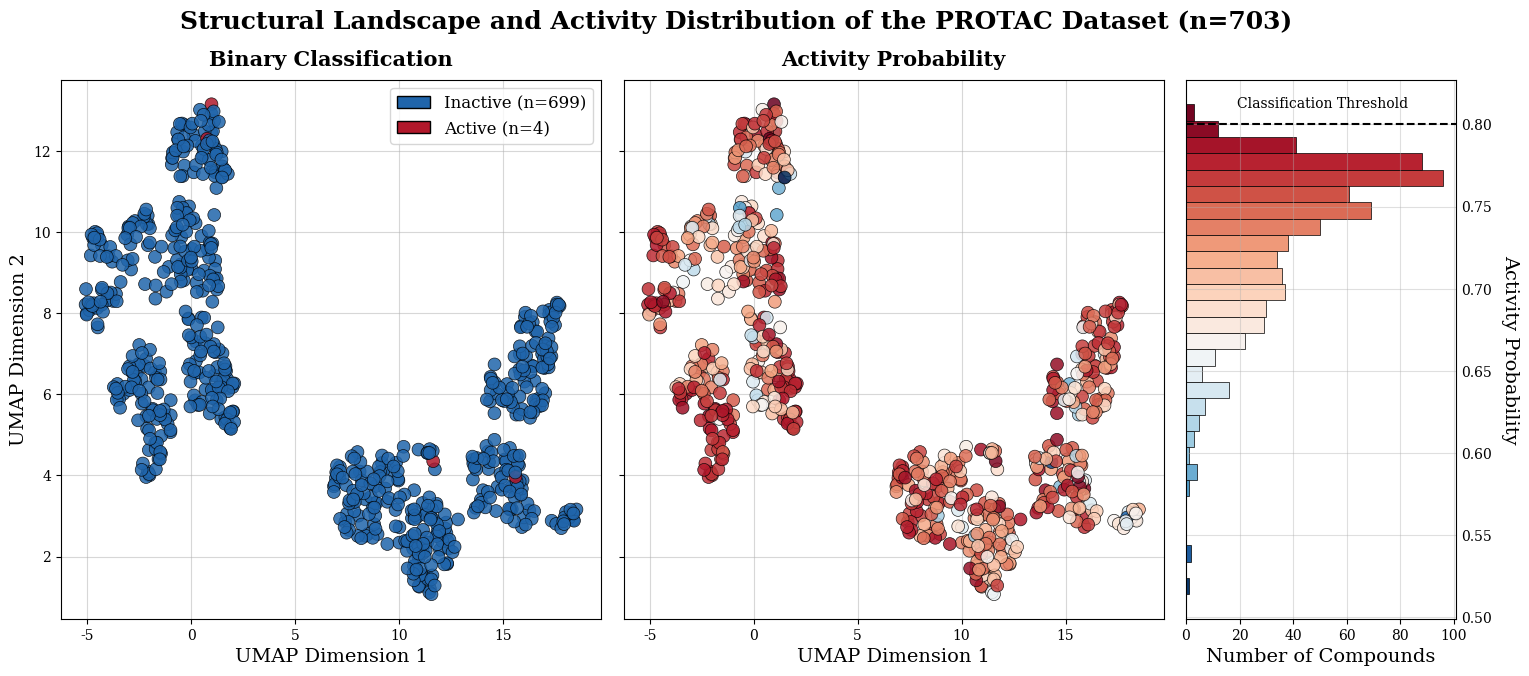

In [20]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.unicode_minus'] = False

# --- DYNAMIC COLOR MAPPING ---
# Calculate the exact boundaries of your actual predictions
prob_min = df_valid['Active_Probability'].min()
prob_max = df_valid['Active_Probability'].max()

# The colormap will now stretch perfectly from prob_min to prob_max
norm = Normalize(vmin=prob_min, vmax=prob_max)
cmap = plt.get_cmap('RdBu_r')

# --- 1x3 Layout ---
fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.05)

ax_umap_class = plt.subplot(gs[0])
ax_umap_prob = plt.subplot(gs[1])
ax_hist = plt.subplot(gs[2]) 

# --- UMAP Plot 1: Binary Class ---
# Extract exact colors from the RdBu_r colormap extremes for the binary plot
color_inactive = cmap(0.10) # Deep Red
color_active = cmap(0.90)   # Deep Blue
class_colors = [color_active if val == 1 else color_inactive for val in df_valid['Active_Class']]

ax_umap_class.scatter(
    embedding[:, 0], embedding[:, 1], 
    c=class_colors, 
    s=85, 
    alpha=0.85, 
    edgecolor='black', 
    linewidth=0.5,
    zorder=3
)

ax_umap_class.set_title('Binary Classification', fontsize=15, fontweight='bold', pad=10)
ax_umap_class.set_xlabel('UMAP Dimension 1', fontsize=14)
ax_umap_class.set_ylabel('UMAP Dimension 2', fontsize=14)
ax_umap_class.grid(True, linestyle='-', alpha=0.5, zorder=1)

# Calculate counts for each class
num_active = (df_valid['Active_Class'] == 1).sum()
num_inactive = (df_valid['Active_Class'] == 0).sum()

# Custom legend for binary class with counts
legend_elements = [
    mpatches.Circle((0, 0), radius=5, facecolor=color_inactive, edgecolor='black', label=f'Inactive (n={num_inactive})'),
    mpatches.Circle((0, 0), radius=5, facecolor=color_active, edgecolor='black', label=f'Active (n={num_active})')
]
ax_umap_class.legend(handles=legend_elements, loc='best', fontsize=12)

# --- UMAP Plot 2: Continuous Probability ---
scatter_prob = ax_umap_prob.scatter(
    embedding[:, 0], embedding[:, 1], 
    c=df_valid['Active_Probability'], 
    cmap=cmap, 
    norm=norm,
    s=85, 
    alpha=0.85, 
    edgecolor='black', 
    linewidth=0.5,
    zorder=3
)

ax_umap_prob.set_title('Activity Probability', fontsize=15, fontweight='bold', pad=10)
ax_umap_prob.set_xlabel('UMAP Dimension 1', fontsize=14)
ax_umap_prob.grid(True, linestyle='-', alpha=0.5, zorder=1)
# Remove y-ticks for the middle plot to keep it clean
ax_umap_prob.set_yticklabels([])
#ax_umap_prob.set_yticks([])

fig.suptitle(f'Structural Landscape and Activity Distribution of the PROTAC Dataset (n={len(df_valid)})', 
             fontsize=18, 
             fontweight='bold', 
             y=0.98)

# --- Vertical Gradient Histogram (The "Dynamic Colorbar") ---
n_bins = 30
counts, bins, patches = ax_hist.hist(
    df_valid['Active_Probability'], 
    bins=n_bins, 
    range=(prob_min, prob_max), # Lock histogram to the actual data range
    orientation='horizontal', 
    edgecolor='black', 
    linewidth=0.5
)

# Color each bar based on the exact center of its probability bin
for bin_left, bin_right, patch in zip(bins[:-1], bins[1:], patches):
    bin_center = (bin_left + bin_right) / 2
    color = cmap(norm(bin_center))
    patch.set_facecolor(color)

ax_hist.set_xlabel('Number of Compounds', fontsize=14)
ax_hist.set_ylabel('Activity Probability', fontsize=14, rotation=270, labelpad=20)
ax_hist.grid(True, axis='y', linestyle='-', alpha=0.4)
ax_hist.grid(True, axis='x', linestyle='-', alpha=0.4)
ax_hist.yaxis.set_label_position("right")
ax_hist.yaxis.tick_right()
ax_hist.tick_params(axis='y', which='both', length=0)

# Add a horizontal dashed line showing your optimal threshold
optimal_threshold = 0.8
ax_hist.axhline(optimal_threshold, color='black', linestyle='--', linewidth=1.5, zorder=5)
ax_hist.text(max(counts)*0.2, optimal_threshold + 0.01, 'Classification Threshold', fontsize=10, color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])